# 데이터 조인

In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# sklearn 데이터 분리 및 검증
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

# 전처리
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# 결측치 처리
from sklearn.impute import SimpleImputer

# 차원축소
from sklearn.decomposition import PCA

# 선형 모델
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# 트리 기반 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor

# 클러스터링
from sklearn.cluster import KMeans

# 평가 지표
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 통계 분석
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

# airbnb_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/AB_NYC_2019.csv')
# attraction_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/nyc_attractions_verified.csv')
# station_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/nyc-transit-subway-entrance-and-exit-data.csv')
# crime_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/NYPD_Complaint_Data_Historic_20260208.csv')

In [3]:
#airbnb_df.head()

In [4]:
# attraction_df.head()

<!-- # 데이터 조인 -->

<!-- ## attraction -->

<!-- ### attraction_count_2km / 3km -->

In [5]:
import numpy as np

# # airbnb 좌표
# airbnb_coords = airbnb_df[['latitude','longitude']].values

# # 관광지 좌표
# attraction_coords = attraction_df[['latitude','longitude']].values

In [6]:
# def haversine(lat1, lon1, lat2, lon2):
#     R = 6371  # Earth radius (km)

#     lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

#     dlat = lat2 - lat1
#     dlon = lon2 - lon1

#     a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
#     c = 2*np.arcsin(np.sqrt(a))

#     return R * c

In [7]:
# counts_2km = []
# counts_3km = []

# for lat, lon in airbnb_coords:
    
#     distances = haversine(
#         lat,
#         lon,
#         attraction_coords[:,0],
#         attraction_coords[:,1]
#     )
    
#     count_2km = np.sum(distances <= 2)
#     count_3km = np.sum(distances <= 3)
    
#     counts_2km.append(count_2km)
#     counts_3km.append(count_3km)

# airbnb_df['attraction_count_2km'] = counts_2km
# airbnb_df['attraction_count_3km'] = counts_3km

In [8]:
# airbnb_df

<!-- ### distance_to_city_center -->

In [9]:
# times_square_lat = 40.7580
# times_square_lon = -73.9855

# airbnb_df['distance_to_city_center'] = haversine(
#     airbnb_df['latitude'],
#     airbnb_df['longitude'],
#     times_square_lat,
#     times_square_lon
# )

In [10]:
# airbnb_df

<!-- ### is_manhattan -->

In [11]:
# airbnb_df['is_manhattan'] = (airbnb_df['neighbourhood_group'] == 'Manhattan').astype(int)

In [12]:
# airbnb_df

In [13]:
# airbnb_df[['attraction_count_2km','attraction_count_3km']].describe()

In [14]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(12,5))

# plt.subplot(1,2,1)
# plt.hist(airbnb_df['attraction_count_2km'], bins=30)
# plt.title('attraction_count_2km distribution')

# plt.subplot(1,2,2)
# plt.hist(airbnb_df['attraction_count_3km'], bins=30)
# plt.title('attraction_count_3km distribution')

# plt.show()

<!-- ## station -->

In [15]:
# station_df[station_df['Station Name'] == '34th St'][[
#     'Station Name',
#     'Line',
#     'Division',
#     'Route1',
#     'Route2',
#     'Route3',
#     'Station Latitude',
#     'Station Longitude'
# ]].drop_duplicates()

<!-- #### station dataset을 feature engineering용으로 정리 -->

In [16]:
# # station dataset을 feature engineering용으로 정리
# station_df = station_df[['Station Name','Station Latitude','Station Longitude']].drop_duplicates()
# # 'Station Name','Station Latitude','Station Longitude'을 기준으로 unique한 station 473개 dataset 저장

# station_df.shape

<!-- #### 지하철 좌표 배열 만들기 -->

In [17]:
# station_lat = station_df['Station Latitude'].values
# station_lon = station_df['Station Longitude'].values

<!-- ### distance_to_nearest_station -->

In [18]:
# nearest_dist = []

# for _, row in airbnb_df.iterrows():

#     dist = haversine(
#         row['latitude'],
#         row['longitude'],
#         station_lat,
#         station_lon
#     )

#     nearest_dist.append(dist.min())

# airbnb_df['distance_to_nearest_station'] = nearest_dist

In [19]:
# airbnb_df[['latitude','longitude','distance_to_nearest_station']].head()

<!-- 각 숙소마다 가장 가까운 지하철까지의 거리(km)


*   0.094923 → 약 95m
*   0.465364 → 약 465m -->

In [20]:
# airbnb_df['distance_to_nearest_station'].describe()

<!-- distance_to_nearest_station의 분포를 히스토그램으로 시각화하여 숙소의 지하철 접근성 분포를 확인하였다. 대부분의 숙소는 약 0.2km ~ 0.5km 범위 내에 위치하며, 일부 외곽 숙소는 지하철과 거리가 크게 떨어진 outlier로 나타났다. -->

In [21]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8,5))
# sns.histplot(
#     airbnb_df[airbnb_df['distance_to_nearest_station'] < 3]['distance_to_nearest_station'],
#     bins=50,
#     kde=True
# )
# plt.xlabel('Distance to Nearest Station (km)')
# plt.title('Distribution (within 3km)')
# plt.show()

<!-- ### station_count
이미 계산한 거리 행렬을 활용해서 반경 내 역 개수 feature를 만든다 -->

In [22]:
# station_counts_300m = []
# station_counts_500m = []
# station_counts_1km = []

# for _, row in airbnb_df.iterrows():

#     dist = haversine(
#         row['latitude'],
#         row['longitude'],
#         station_lat,
#         station_lon
#     )

#     station_counts_300m.append((dist <= 0.3).sum())
#     station_counts_500m.append((dist <= 0.5).sum())
#     station_counts_1km.append((dist <= 1).sum())


# airbnb_df['station_count_300m'] = station_counts_300m
# airbnb_df['station_count_500m'] = station_counts_500m
# airbnb_df['station_count_1km'] = station_counts_1km

In [23]:
# airbnb_df[[
#     'distance_to_nearest_station',
#     'station_count_300m',
#     'station_count_500m',
#     'station_count_1km'
# ]].head()

In [24]:
# airbnb_df[[
#     'station_count_300m',
#     'station_count_500m',
#     'station_count_1km'
# ]].describe()

In [25]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# cols = [
#     'station_count_300m',
#     'station_count_500m',
#     'station_count_1km'
# ]

# plt.figure(figsize=(10,6))

# for i, col in enumerate(cols, 1):
#     plt.subplot(1,3,i)
#     sns.histplot(airbnb_df[col], bins=30)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

In [26]:
# col = airbnb_df.pop('station_count_300m')
# airbnb_df.insert(
#     airbnb_df.columns.get_loc('station_count_500m'),
#     'station_count_300m',
#     col
# )

In [27]:
# airbnb_df.head()

<!-- ## crime -->

In [28]:
# from sklearn.neighbors import BallTree
# a_coords = np.radians(airbnb_df[['latitude','longitude']].values)
# crime_coords = np.radians(crime_df[['Latitude','Longitude']].values)

# crime_tree = BallTree(crime_coords, metric='haversine')

In [29]:
# earth_radius = 6371

# r05 = 0.5 / earth_radius
# r1  = 1 / earth_radius
# r2  = 2 / earth_radius

<!-- ### crime_count -->

In [30]:
# c05 = crime_tree.query_radius(a_coords, r=r05, count_only=True)
# c1  = crime_tree.query_radius(a_coords, r=r1, count_only=True)
# c2  = crime_tree.query_radius(a_coords, r=r2, count_only=True)

# airbnb_df['crime_count_0.5km'] = c05
# airbnb_df['crime_count_1km'] = c1
# airbnb_df['crime_count_2km'] = c2

<!-- ### felony_count -->

In [31]:
# felony_df = crime_df[crime_df['LAW_CAT_CD']=='FELONY']

# coords = np.radians(felony_df[['Latitude','Longitude']].values)
# tree = BallTree(coords, metric='haversine')

# f05 = tree.query_radius(a_coords, r=r05, count_only=True)
# f1  = tree.query_radius(a_coords, r=r1, count_only=True)
# f2  = tree.query_radius(a_coords, r=r2, count_only=True)

# airbnb_df['felony_count_0.5km'] = f05
# airbnb_df['felony_count_1km'] = f1
# airbnb_df['felony_count_2km'] = f2

<!-- ### misdemeanor_count -->

In [32]:
# mis_df = crime_df[crime_df['LAW_CAT_CD']=='MISDEMEANOR']

# coords = np.radians(mis_df[['Latitude','Longitude']].values)
# tree = BallTree(coords, metric='haversine')

# m05 = tree.query_radius(a_coords, r=r05, count_only=True)
# m1  = tree.query_radius(a_coords, r=r1, count_only=True)
# m2  = tree.query_radius(a_coords, r=r2, count_only=True)

# airbnb_df['misdemeanor_count_0.5km'] = m05
# airbnb_df['misdemeanor_count_1km'] = m1
# airbnb_df['misdemeanor_count_2km'] = m2

<!-- ### night_crime_count -->

In [33]:
# crime_df['CMPLNT_FR_TM'] = pd.to_datetime(crime_df['CMPLNT_FR_TM'],format='%H:%M:%S',errors='coerce')
# crime_df['hour'] = crime_df['CMPLNT_FR_TM'].dt.hour

# night_df = crime_df[(crime_df['hour']>=22)|(crime_df['hour']<6)]

# coords = np.radians(night_df[['Latitude','Longitude']].values)
# tree = BallTree(coords, metric='haversine')

# n05 = tree.query_radius(a_coords, r=r05, count_only=True)
# n1  = tree.query_radius(a_coords, r=r1, count_only=True)
# n2  = tree.query_radius(a_coords, r=r2, count_only=True)

# airbnb_df['night_crime_count_0.5km'] = n05
# airbnb_df['night_crime_count_1km'] = n1
# airbnb_df['night_crime_count_2km'] = n2

<!-- ### ratio 계산 -->

In [34]:
# for r in ['0.5km','1km','2km']:

#     airbnb_df[f'felony_ratio_{r}'] = airbnb_df[f'felony_count_{r}'] / airbnb_df[f'crime_count_{r}']
#     airbnb_df[f'misdemeanor_ratio_{r}'] = airbnb_df[f'misdemeanor_count_{r}'] / airbnb_df[f'crime_count_{r}']
#     airbnb_df[f'night_crime_ratio_{r}'] = airbnb_df[f'night_crime_count_{r}'] / airbnb_df[f'crime_count_{r}']

In [35]:
# pd.set_option('display.max_columns', None)

<!-- # 최종 airbnb_df -->

In [36]:
# airbnb_df.head()

In [37]:
# airbnb_df.isnull().sum().loc[lambda x: x > 0]

In [38]:
import pandas as pd
import numpy as np

airbnb_df = pd.read_csv('airbnb_final.csv')

# 데이터 전처리

In [39]:
num_cols = airbnb_df.select_dtypes(include=np.number).columns.tolist()
display(airbnb_df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.000000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.000000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.499790,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.244420,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.000000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.000000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.000000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.010000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.000000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.000000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02



===== price quantile =====
0.00        0.0
0.01       30.0
0.05       40.0
0.25       69.0
0.50      106.0
0.75      175.0
0.95      355.0
0.99      799.0
1.00    10000.0
Name: price, dtype: float64


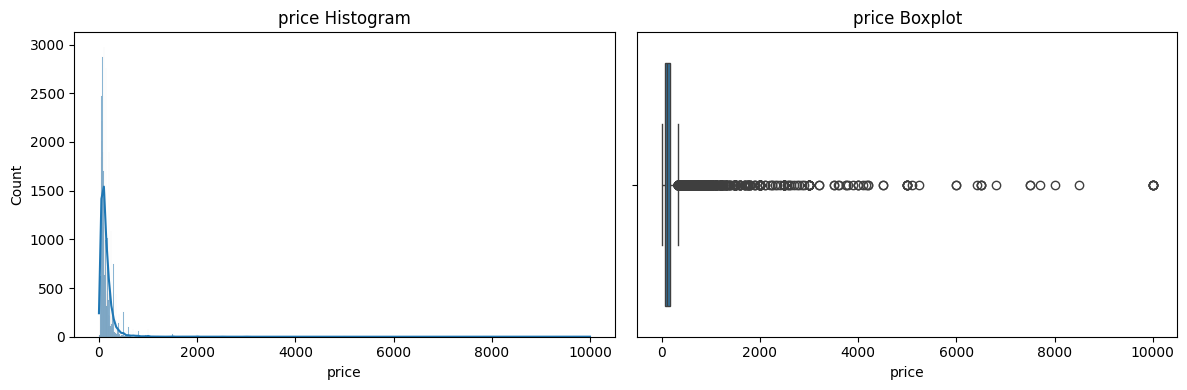


===== minimum_nights quantile =====
0.00       1.0
0.01       1.0
0.05       1.0
0.25       1.0
0.50       3.0
0.75       5.0
0.95      30.0
0.99      45.0
1.00    1250.0
Name: minimum_nights, dtype: float64


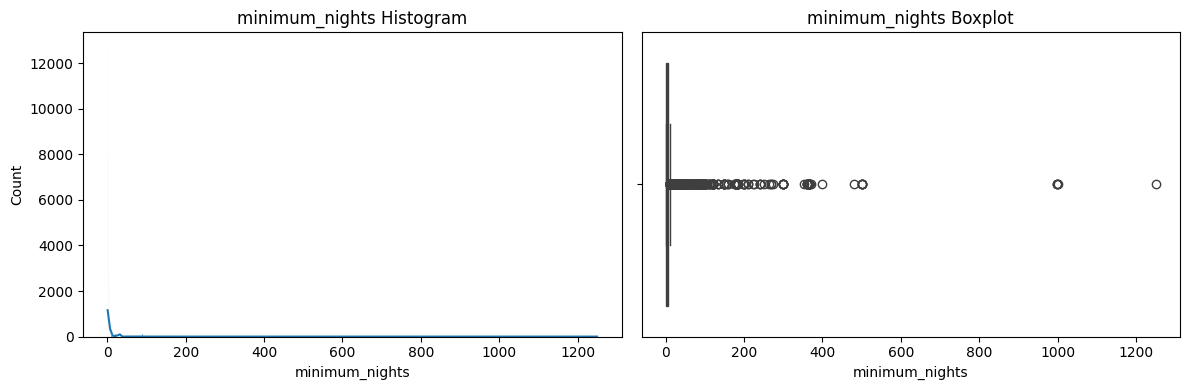


===== number_of_reviews quantile =====
0.00      0.0
0.01      0.0
0.05      0.0
0.25      1.0
0.50      5.0
0.75     24.0
0.95    114.0
0.99    214.0
1.00    629.0
Name: number_of_reviews, dtype: float64


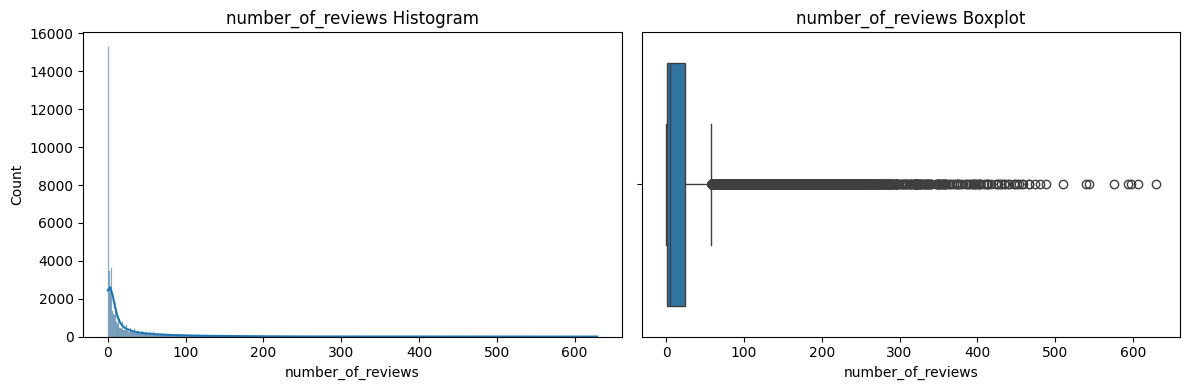


===== reviews_per_month quantile =====
0.00     0.0100
0.01     0.0200
0.05     0.0400
0.25     0.1900
0.50     0.7200
0.75     2.0200
0.95     4.6400
0.99     7.1958
1.00    58.5000
Name: reviews_per_month, dtype: float64


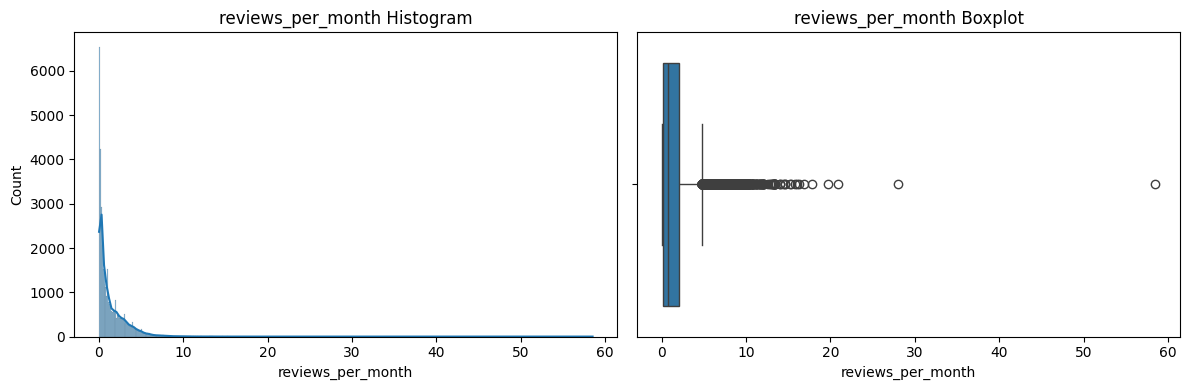

In [40]:
check_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']

for col in check_cols:
    if col in airbnb_df.columns:
        print(f'\n===== {col} quantile =====')
        print(airbnb_df[col].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(airbnb_df[col], kde=True, ax=axes[0])
        axes[0].set_title(f'{col} Histogram')
        sns.boxplot(x=airbnb_df[col], ax=axes[1])
        axes[1].set_title(f'{col} Boxplot')
        plt.tight_layout()
        plt.show()

In [41]:
skew_df = pd.DataFrame({
    'skewness': airbnb_df[num_cols].skew()
}).sort_values(by='skewness', ascending=False)
display(skew_df)

,skewness
minimum_nights,21.827275
price,19.118939
distance_to_nearest_station,9.407781
calculated_host_listings_count,7.933174
number_of_reviews,3.690635
station_count_300m,3.384947
reviews_per_month,3.130189
station_count_500m,2.920116
station_count_1km,1.779903
attraction_count_2km,1.409347


## 결측치 처리

In [42]:
airbnb_df.isnull().sum().loc[lambda x: x > 0]

name                          16
host_name                     21
last_review                10052
reviews_per_month          10052
felony_ratio_0.5km             5
misdemeanor_ratio_0.5km        5
night_crime_ratio_0.5km        5
dtype: int64

### name / host_name 결측치 처리

In [43]:
airbnb_df = airbnb_df.drop(columns=['name'])
airbnb_df = airbnb_df.drop(columns=['host_name'])

### last_review 결측치 처리

In [44]:
airbnb_df = airbnb_df.drop(columns=['last_review'])

### reviews_per_month

In [45]:
airbnb_df['reviews_per_month'] = airbnb_df['reviews_per_month'].fillna(0)

### crime ratio 결측치 처리

In [46]:
airbnb_df[
    (airbnb_df['crime_count_0.5km'] == 0) &
    (airbnb_df['felony_count_0.5km'] > 0)
]

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,night_crime_count_2km,felony_ratio_0.5km,misdemeanor_ratio_0.5km,night_crime_ratio_0.5km,felony_ratio_1km,misdemeanor_ratio_1km,night_crime_ratio_1km,felony_ratio_2km,misdemeanor_ratio_2km,night_crime_ratio_2km


In [47]:
ratio_cols = [
    'felony_ratio_0.5km',
    'misdemeanor_ratio_0.5km',
    'night_crime_ratio_0.5km'
]

airbnb_df[ratio_cols] = airbnb_df[ratio_cols].fillna(0)

In [48]:
airbnb_df.isnull().sum().loc[lambda x: x > 0]

Series([], dtype: int64)

## 이상치 처리

In [49]:
airbnb_df = airbnb_df[airbnb_df['price'] > 0]

price_upper = airbnb_df['price'].quantile(0.99)
airbnb_df = airbnb_df[airbnb_df['price'] <= price_upper]

In [50]:
upper = airbnb_df['minimum_nights'].quantile(0.99)
airbnb_df = airbnb_df[airbnb_df['minimum_nights'] <= upper]


===== price quantile =====
0.00     10.0
0.01     30.0
0.05     40.0
0.25     69.0
0.50    105.0
0.75    175.0
0.95    345.0
0.99    550.0
1.00    799.0
Name: price, dtype: float64


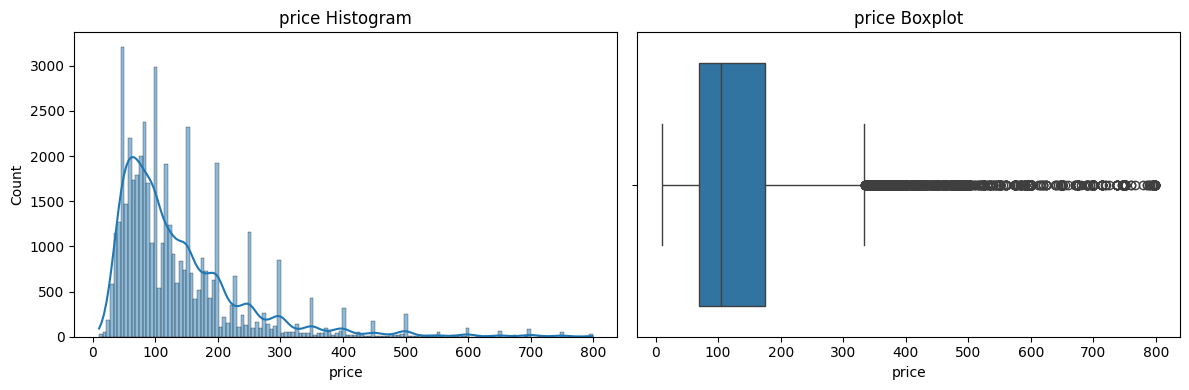


===== minimum_nights quantile =====
0.00     1.0
0.01     1.0
0.05     1.0
0.25     1.0
0.50     2.0
0.75     5.0
0.95    30.0
0.99    30.0
1.00    40.0
Name: minimum_nights, dtype: float64


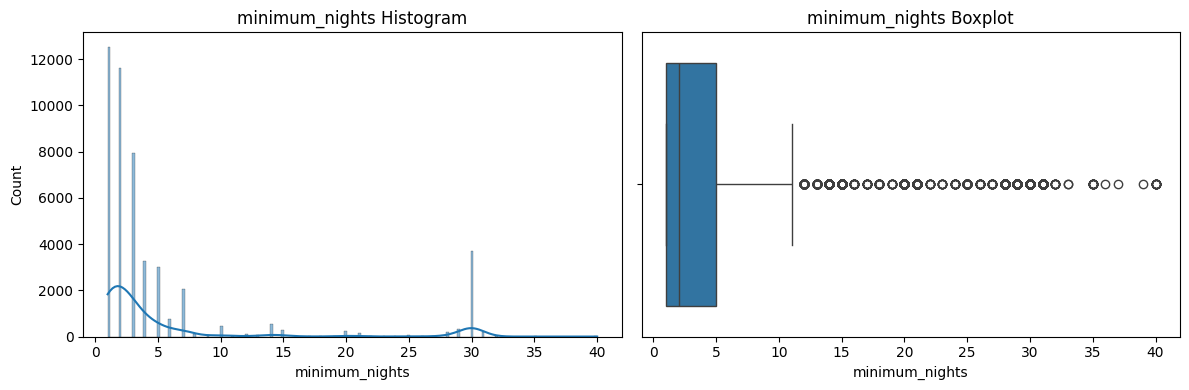


===== number_of_reviews quantile =====
0.00      0.0
0.01      0.0
0.05      0.0
0.25      1.0
0.50      5.0
0.75     24.0
0.95    115.0
0.99    214.0
1.00    629.0
Name: number_of_reviews, dtype: float64


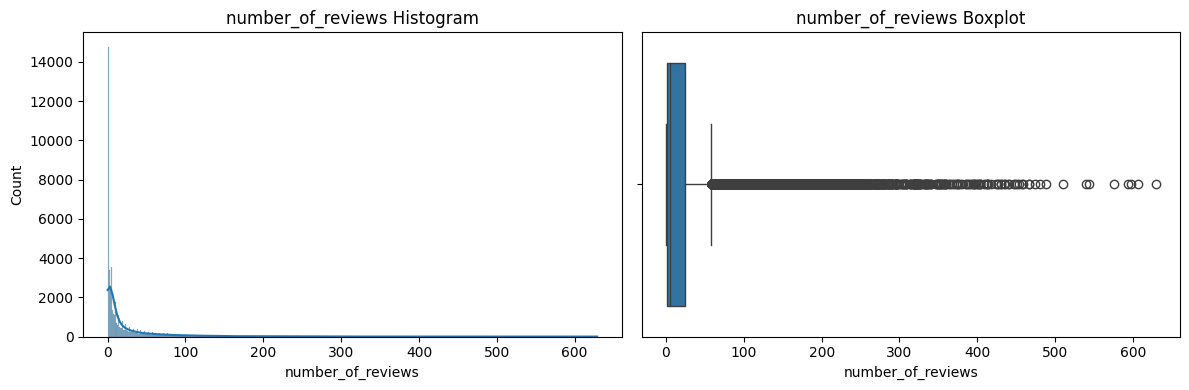


===== reviews_per_month quantile =====
0.00     0.0000
0.01     0.0000
0.05     0.0000
0.25     0.0400
0.50     0.3800
0.75     1.6200
0.95     4.3400
0.99     6.8373
1.00    58.5000
Name: reviews_per_month, dtype: float64


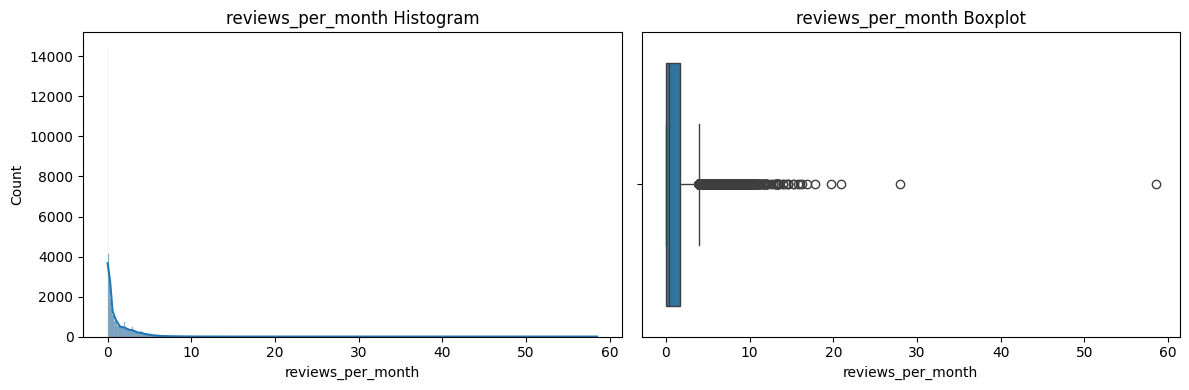

In [51]:
check_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']

for col in check_cols:
    if col in airbnb_df.columns:
        print(f'\n===== {col} quantile =====')
        print(airbnb_df[col].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(airbnb_df[col], kde=True, ax=axes[0])
        axes[0].set_title(f'{col} Histogram')
        sns.boxplot(x=airbnb_df[col], ax=axes[1])
        axes[1].set_title(f'{col} Boxplot')
        plt.tight_layout()
        plt.show()

In [52]:
skew_df = pd.DataFrame({
    'skewness': airbnb_df[num_cols].skew()
}).sort_values(by='skewness', ascending=False)
display(skew_df)

,skewness
distance_to_nearest_station,9.316855
calculated_host_listings_count,7.910868
number_of_reviews,3.667502
station_count_300m,3.403368
reviews_per_month,3.285039
station_count_500m,2.928943
minimum_nights,2.297880
price,2.273991
station_count_1km,1.794295
attraction_count_2km,1.434235


## log 변환

In [53]:
import numpy as np

log_cols = [
    'minimum_nights',
    'distance_to_nearest_station',
    'calculated_host_listings_count',
    'number_of_reviews',
    'reviews_per_month',
    'station_count_300m',
    'station_count_500m',
    'price'
]

for col in log_cols:
    if col in airbnb_df.columns:
        airbnb_df[f'log_{col}'] = np.log1p(airbnb_df[col])

In [54]:
for col in log_cols:
    if col in airbnb_df.columns:
        print(col, "skew before:", airbnb_df[col].skew())
        print("log skew:", airbnb_df[f'log_{col}'].skew())
        print()

minimum_nights skew before: 2.2978804955629606
log skew: 1.3050452034327278

distance_to_nearest_station skew before: 9.316855097355363
log skew: 3.6783778959280453

calculated_host_listings_count skew before: 7.9108676429531055
log skew: 3.2845786617233927

number_of_reviews skew before: 3.6675021770080716
log skew: 0.35381280646742036

reviews_per_month skew before: 3.2850388282467864
log skew: 0.9332861778767801

station_count_300m skew before: 3.403367914929562
log skew: 0.8219458366025185

station_count_500m skew before: 2.9289425924185615
log skew: 0.24868803172523554

price skew before: 2.2739914180632343
log skew: 0.2371220303463953



In [55]:
airbnb_df

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,misdemeanor_ratio_2km,night_crime_ratio_2km,log_minimum_nights,log_distance_to_nearest_station,log_calculated_host_listings_count,log_number_of_reviews,log_reviews_per_month,log_station_count_300m,log_station_count_500m,log_price
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,...,0.515096,0.242109,0.693147,0.382104,1.945910,2.302585,0.190620,0.000000,0.693147,5.010635
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,...,0.540041,0.205736,0.693147,0.090684,1.098612,3.828641,0.322083,1.386294,1.945910,5.420535
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,...,0.578210,0.206138,1.386294,0.287966,0.693147,0.000000,0.000000,0.000000,0.693147,5.017280
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,...,0.524755,0.221725,0.693147,0.347774,0.693147,5.602119,1.729884,0.000000,1.098612,4.499810
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,...,0.571406,0.205123,2.397895,0.182477,0.693147,2.302585,0.095310,0.693147,1.098612,4.394449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,...,0.508797,0.232477,1.098612,0.195504,1.098612,0.000000,0.000000,0.693147,0.693147,4.262680
48891,36485057,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,...,0.504964,0.255532,1.609438,0.391688,1.098612,0.000000,0.000000,0.000000,0.693147,3.713572
48892,36485431,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,...,0.574718,0.206491,2.397895,0.307485,0.693147,0.000000,0.000000,0.000000,0.693147,4.753590
48893,36485609,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,...,0.538437,0.214690,0.693147,0.112255,1.945910,0.000000,0.000000,0.693147,1.609438,4.025352


In [56]:
quantiles = airbnb_df['minimum_nights'].quantile(
    [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
)

quantiles

0.00     1.0
0.25     1.0
0.50     2.0
0.75     5.0
0.90    20.0
0.95    30.0
0.99    30.0
1.00    40.0
Name: minimum_nights, dtype: float64

In [57]:
quantiles = airbnb_df['minimum_nights'].quantile(
    [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
)

bins = pd.Index(quantiles.values).unique()

airbnb_df['minimum_nights'].value_counts(bins=bins, sort=False)

(0.999, 2.0]    24162
(2.0, 5.0]      14220
(5.0, 20.0]      4776
(20.0, 30.0]     4534
(30.0, 40.0]      236
Name: count, dtype: int64

## 위 내용까지 정연님이 작성
## 아래는 본인

In [74]:
# 로그변환 안된 원본 컬럼 제거 (로그변환된 버전이 있는 것들)
log_cols = [c for c in airbnb_df.columns if c.startswith('log_')]
original_cols = [c.replace('log_', '') for c in log_cols]

airbnb_df = airbnb_df.drop(columns=original_cols, errors='ignore')
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47928 entries, 0 to 48894
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  47928 non-null  int64  
 1   host_id                             47928 non-null  int64  
 2   neighbourhood_group                 47928 non-null  object 
 3   neighbourhood                       47928 non-null  object 
 4   latitude                            47928 non-null  float64
 5   longitude                           47928 non-null  float64
 6   room_type                           47928 non-null  object 
 7   availability_365                    47928 non-null  int64  
 8   attraction_count_2km                47928 non-null  int64  
 9   attraction_count_3km                47928 non-null  int64  
 10  distance_to_city_center             47928 non-null  float64
 11  is_manhattan                        47928 non-

In [59]:
#airbnb_df.to_csv("모든 전처리 완료한 데이터셋", index=False, encoding="utf-8-sig")

In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

crime_cols = [c for c in airbnb_df.columns if 'crime' in c or 'felony' in c or 'misdemeanor' in c]

# 상관관계
print("=== 상관관계 (log_price 기준) ===")
print(airbnb_df[crime_cols + ['log_price']].corr()['log_price'].drop('log_price').sort_values(ascending=False))

# VIF
print("\n=== VIF ===")
vif_data = airbnb_df[crime_cols].dropna()
vif = pd.DataFrame()
vif['feature'] = crime_cols
vif['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(len(crime_cols))]
print(vif.sort_values('VIF', ascending=False))

=== 상관관계 (log_price 기준) ===
felony_count_2km           0.281844
felony_count_1km           0.281699
felony_count_0.5km         0.269017
misdemeanor_count_2km      0.267779
misdemeanor_count_1km      0.266185
crime_count_1km            0.258958
crime_count_2km            0.255203
misdemeanor_count_0.5km    0.251909
crime_count_0.5km          0.248668
misdemeanor_ratio_2km      0.229122
night_crime_count_1km      0.215706
night_crime_count_0.5km    0.212531
night_crime_count_2km      0.197328
misdemeanor_ratio_1km      0.170587
felony_ratio_2km           0.153003
misdemeanor_ratio_0.5km    0.124261
felony_ratio_1km           0.115935
felony_ratio_0.5km         0.092302
night_crime_ratio_0.5km   -0.121078
night_crime_ratio_1km     -0.217997
night_crime_ratio_2km     -0.326212
Name: log_price, dtype: float64

=== VIF ===
                    feature           VIF
1           crime_count_1km  21988.822463
2           crime_count_2km  18036.742747
7     misdemeanor_count_1km   8706.035850
8  

In [77]:
vif_data = airbnb_df[crime_final].dropna()
vif = pd.DataFrame()
vif['feature'] = crime_final
vif['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(len(crime_final))]
print(vif)

                 feature        VIF
0       felony_ratio_1km  56.702592
1  misdemeanor_ratio_1km  43.982546
2  night_crime_ratio_1km  38.478129


In [78]:
attraction_cols = ['attraction_count_2km', 'attraction_count_3km']

vif_data = airbnb_df[attraction_cols].dropna()
vif = pd.DataFrame()
vif['feature'] = attraction_cols
vif['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(len(attraction_cols))]
print(airbnb_df[attraction_cols + ['log_price']].corr()['log_price'])
print(vif)

attraction_count_2km    0.424469
attraction_count_3km    0.467104
log_price               1.000000
Name: log_price, dtype: float64
                feature        VIF
0  attraction_count_2km  10.131236
1  attraction_count_3km  10.131236


In [79]:
station_cols = ['log_station_count_300m', 'log_station_count_500m', 'station_count_1km', 'log_distance_to_nearest_station']

print("=== VIF ===")
vif_data = airbnb_df[station_cols].dropna()
vif = pd.DataFrame()
vif['feature'] = station_cols
vif['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(len(station_cols))]
print(vif)

print("\n=== log_price 상관관계 ===")
print(airbnb_df[station_cols + ['log_price']].corr()['log_price'])

=== VIF ===
                           feature       VIF
0           log_station_count_300m  3.107451
1           log_station_count_500m  6.746847
2                station_count_1km  5.519382
3  log_distance_to_nearest_station  1.289711

=== log_price 상관관계 ===
log_station_count_300m             0.136546
log_station_count_500m             0.206117
station_count_1km                  0.315935
log_distance_to_nearest_station   -0.120897
log_price                          1.000000
Name: log_price, dtype: float64


In [81]:
num_cols = [
    'log_minimum_nights', 'log_calculated_host_listings_count',
    'log_number_of_reviews', 'log_reviews_per_month',
    'availability_365', 'distance_to_city_center', 'is_manhattan',
    'station_count_1km', 'log_station_count_300m', 'log_station_count_500m',
    'log_distance_to_nearest_station', 'attraction_count_3km', 'felony_ratio_1km'
]

print(airbnb_df[num_cols + ['log_price']].corr()['log_price'].drop('log_price').sort_values(ascending=False))

attraction_count_3km                  0.467104
is_manhattan                          0.354190
station_count_1km                     0.315935
log_station_count_500m                0.206117
log_station_count_300m                0.136546
felony_ratio_1km                      0.115935
availability_365                      0.086515
log_minimum_nights                    0.070443
log_calculated_host_listings_count    0.056055
log_reviews_per_month                -0.048095
log_number_of_reviews                -0.050326
log_distance_to_nearest_station      -0.120897
distance_to_city_center              -0.400677
Name: log_price, dtype: float64


In [83]:
pd.set_option('display.max_columns', None)
airbnb_df.head(1)

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,availability_365,attraction_count_2km,attraction_count_3km,distance_to_city_center,is_manhattan,station_count_1km,crime_count_0.5km,crime_count_1km,crime_count_2km,felony_count_0.5km,felony_count_1km,felony_count_2km,misdemeanor_count_0.5km,misdemeanor_count_1km,misdemeanor_count_2km,night_crime_count_0.5km,night_crime_count_1km,night_crime_count_2km,felony_ratio_0.5km,misdemeanor_ratio_0.5km,night_crime_ratio_0.5km,felony_ratio_1km,misdemeanor_ratio_1km,night_crime_ratio_1km,felony_ratio_2km,misdemeanor_ratio_2km,night_crime_ratio_2km,log_minimum_nights,log_distance_to_nearest_station,log_calculated_host_listings_count,log_number_of_reviews,log_reviews_per_month,log_station_count_300m,log_station_count_500m,log_price
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,365,1,2,12.337898,0,4,385,1856,8744,128,588,2899,179,961,4504,86,415,2117,0.332468,0.464935,0.223377,0.31681,0.51778,0.223599,0.331542,0.515096,0.242109,0.693147,0.382104,1.94591,2.302585,0.19062,0.0,0.693147,5.010635
